

1.   ARAFANG SANNEH
2.   MUHAMMED L DAFFEH
3.   ASAD


EXPLORATORY DATA ANALYSIS (EDA) WITH PANDAS

### 1. Import pandas library

This cell imports the pandas library, which is essential for data manipulation and analysis in Python. It's aliased as `pd` for convenience.

In [ ]:
import pandas as pd

### 2. Load the dataset

This cell loads the `movies_data.csv.xls` file into a pandas DataFrame named `df`. This is the first step in bringing our data into the notebook for analysis.

In [ ]:
df=pd.read_csv("/content/movies_data.csv.xls")

### 3. Display the first 2 rows of the DataFrame

`df.head(2)` is used to quickly inspect the first two rows of the DataFrame. This helps to understand the structure of the data, the column names, and the types of values present.

In [ ]:
df.head(2)

,Unnamed: 0,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,0,False,/9Z2uDYXqJrlmePznQQJhL6d92Rq.jpg,"[10751, 35, 12, 14, 16]",1226863,en,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,780.1539,/eJGWx219ZcEMVQJhAgMiqo8tYY.jpg,2026-04-01,The Super Mario Galaxy Movie,False,6.809,504
1,1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,"[10749, 18]",1523145,ru,Твоё сердце будет разбито,High school student Polina is saved from bully...,384.6462,/7wIBfBl2gejt6xHxNSK0reVIm7E.jpg,2026-03-26,Your Heart Will Be Broken,False,7.094,64


### 4. Check the shape of the DataFrame

`df.shape` returns a tuple representing the dimensionality of the DataFrame (number of rows, number of columns). This gives a quick overview of the dataset size.

In [ ]:
df.shape

(3980, 15)

### 5. Display column names

`df.columns` provides a list of all column names in the DataFrame. This is useful for understanding the available features and for referencing them in subsequent operations.

In [ ]:
df.columns

Index(['Unnamed: 0', 'adult', 'backdrop_path', 'genre_ids', 'id',
       'original_language', 'original_title', 'overview', 'popularity',
       'poster_path', 'release_date', 'title', 'video', 'vote_average',
       'vote_count'],
      dtype='object')

### 6. Get concise summary of the DataFrame

`df.info()` prints a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage. This is crucial for identifying missing values and understanding data types.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3980 entries, 0 to 3979
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3980 non-null   int64  
 1   adult              3980 non-null   bool   
 2   backdrop_path      3925 non-null   object 
 3   genre_ids          3980 non-null   object 
 4   id                 3980 non-null   int64  
 5   original_language  3980 non-null   object 
 6   original_title     3980 non-null   object 
 7   overview           3952 non-null   object 
 8   popularity         3980 non-null   float64
 9   poster_path        3974 non-null   object 
 10  release_date       3973 non-null   object 
 11  title              3980 non-null   object 
 12  video              3980 non-null   bool   
 13  vote_average       3980 non-null   float64
 14  vote_count         3980 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(8)
memory usage: 412.1+ KB


### 7. Check for missing values

`df.isnull().sum()` calculates the number of missing (null) values for each column. This helps identify columns with incomplete data that might require cleaning.

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
adult,0
backdrop_path,55
genre_ids,0
id,0
original_language,0
original_title,0
overview,28
popularity,0
poster_path,6


### 8. Handle missing values

This cell first drops rows where critical columns (`release_date`, `poster_path`, `overview`, `backdrop_path`) have missing values, as these are important for movie data. Then, it fills any remaining null values in the entire DataFrame with `0`. This ensures that all entries have a value and prevents potential errors in further analysis.

In [ ]:
df = df.dropna(subset=["release_date","poster_path","overview","backdrop_path"])
df.fillna(0, inplace=True)

### 9. Check for duplicate rows

`df.duplicated().sum()` counts the total number of duplicate rows in the DataFrame. Identifying and handling duplicates is an important step in data cleaning to ensure data integrity.

In [ ]:
df.duplicated().sum()


np.int64(0)

### 10. Remove duplicate rows

`df.drop_duplicates()` removes any identified duplicate rows from the DataFrame, keeping only the first occurrence by default. This ensures that each movie entry is unique.

In [ ]:
df = df.drop_duplicates()

### 11. Generate descriptive statistics

`df.describe()` generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution for numerical columns, excluding `NaN` values. This gives a quick overview of the data's statistical properties.

In [ ]:
df.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,3910.000000,3.910000e+03,3910.000000,3910.000000,3910.000000
mean,1985.866752,4.054582e+05,10.459472,6.656560,3679.718926
std,1150.146664,4.812603e+05,21.086076,1.291278,4809.378952
min,0.000000,1.100000e+01,2.057200,0.000000,0.000000
25%,990.250000,1.019225e+04,5.454350,6.250000,318.000000
50%,1980.500000,1.550005e+05,7.095100,6.838500,2113.500000
75%,2981.750000,7.152430e+05,9.792050,7.383000,4894.000000
max,3979.000000,1.669057e+06,780.153900,10.000000,39407.000000


### 12. Display value counts for key numerical columns

This cell calculates and displays the frequency of unique combinations of `popularity`, `vote_average`, and `vote_count`. This helps in understanding the distribution and common patterns within these specific numerical features.

In [ ]:
df[['popularity','vote_average','vote_count']].value_counts()

,,,count
popularity,vote_average,vote_count,
4.9973,8.400,35,2
6.7128,6.608,1809,2
6.7068,5.946,676,2
11.0512,7.100,74,2
3.9778,6.277,110,2
...,...,...,...
6.0431,6.251,5263,1
6.0481,5.530,2012,1
6.0497,6.068,5765,1


### 13. Plot histogram of `vote_average`

This code generates a histogram of the `vote_average` column using `matplotlib.pyplot`. A histogram visually represents the distribution of numerical data, showing how frequently different `vote_average` scores appear. The `bins=20` argument divides the data into 20 intervals.

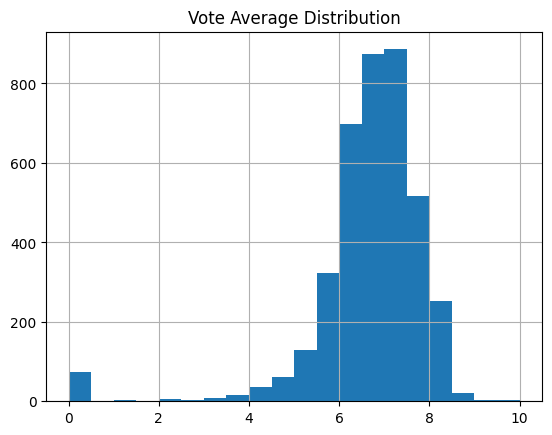

In [ ]:
import matplotlib.pyplot as plt

df['vote_average'].hist(bins=20)
plt.title("Vote Average Distribution")
plt.show()

### 14. Calculate correlation matrix

This cell calculates the pairwise correlation between `popularity`, `vote_average`, and `vote_count`. The correlation matrix helps in understanding the linear relationship between these numerical variables. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation.

In [ ]:
df[['popularity','vote_average','vote_count']].corr()

,popularity,vote_average,vote_count
popularity,1.000000,0.013376,0.066306
vote_average,0.013376,1.000000,0.305907
vote_count,0.066306,0.305907,1.000000


### 15. Plot scatter plot of `popularity` vs `vote_count`

This cell generates a scatter plot to visualize the relationship between `popularity` and `vote_count`. Each point on the plot represents a movie, with its x-coordinate being its popularity and its y-coordinate being its vote count. Scatter plots are useful for identifying trends, correlations, or clusters between two numerical variables.

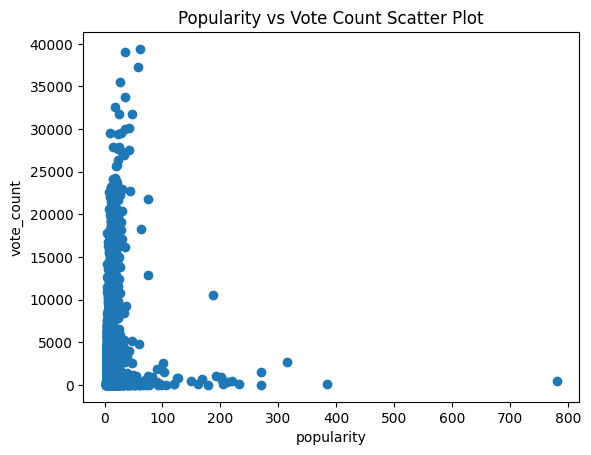

In [ ]:
plt.scatter(df['popularity'], df['vote_count'])
plt.xlabel("popularity")
plt.ylabel("vote_count")
plt.title("Popularity vs Vote Count Scatter Plot")
plt.show()

### 16. Identify top 5 movies by popularity

This cell uses the `nlargest()` method to select the top 5 movies based on their 'popularity' score. It then displays only the 'title' and 'popularity' columns of these top movies, providing a quick summary of the most popular films in the dataset.